# 8) Model Benchmarking & Results

**Siemens Advanta BC — Revenue Forecasting**  
*NOVA IMS | MSc Data Science & Advanced Analytics | 2025–26*

---

This notebook consolidates all forecasting approaches explored across notebooks 6a–6d into a single,
self-contained reference for model performance evaluation.

**Experimental setup:**
| | |
|---|---|
| Train | Periods 1–36 |
| Validation | Periods 37–42 |
| Test (blind) | Periods 43–48 |
| Target | Revenue cons. (anon) |
| Series | 134 TGL Business Subsegments |
| Horizon | 6 periods ahead |
| Primary metrics | RMSE, MAE, wMAPE, R² |


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.float_format", "{:,.2f}".format)
pd.set_option("display.max_columns", 20)

APPROACH_COLORS = {
    "TS Baselines":         "#0F766E",
    "ML Recursive":         "#1D4ED8",
    "ML Direct Multi-Step": "#7C3AED",
    "Foundation Models":    "#B45309",
    "Walk-Forward CV":      "#065F46",
}
WINNER_COLOR = "#F59E0B"

print("✓ Imports OK")


✓ Imports OK


---
## 1. Data — All Model Results

Results are copied directly from notebook outputs (validation set, periods 37–42).
Each approach section contains results broken down **by hierarchical level**
(Subsegment → Segment → BU) where available.


In [2]:
# ── 6a: TS Baselines ─────────────────────────────────────────────────────────
# All TS models operate on the raw series — no engineered features.
# Level is effectively "Subsegment" (one model per series).
df_baselines = pd.DataFrame([
    {"Model": "Moving Avg (6)",      "RMSE":  9_709_532, "MAE": 4_588_482, "wMAPE": 12.0, "R2": 0.9796, "Winner": True},
    {"Model": "Chronos (Zero-Shot)", "RMSE": 10_752_788, "MAE": 4_835_689, "wMAPE": 12.5, "R2": 0.9752},
    {"Model": "Moving Avg (3)",      "RMSE": 11_403_219, "MAE": 5_406_896, "wMAPE": 14.1, "R2": 0.9719},
    {"Model": "Prophet",             "RMSE": 12_154_381, "MAE": 5_770_040, "wMAPE": 14.9, "R2": 0.9683},
    {"Model": "Seasonal Naïve",      "RMSE": 12_800_528, "MAE": 5_346_114, "wMAPE": 14.0, "R2": 0.9645},
    {"Model": "ETS (Holt-Winters)",  "RMSE": 14_377_822, "MAE": 6_289_845, "wMAPE": 16.4, "R2": 0.9553},
    {"Model": "SARIMA",              "RMSE": 14_774_150, "MAE": 5_923_012, "wMAPE": 15.3, "R2": 0.9538},
    {"Model": "VAR",                 "RMSE": 16_254_747, "MAE": 7_348_745, "wMAPE": 16.2, "R2": 0.9493},
    {"Model": "Naïve",               "RMSE": 20_881_478, "MAE": 9_968_088, "wMAPE": 26.0, "R2": 0.9056},
]).fillna({"Winner": False})

# ── 6a: ML Recursive — by level ──────────────────────────────────────────────
df_recursive = pd.DataFrame([
    # Subsegment
    {"Model": "Random Forest",     "Level": "Subsegment", "RMSE": 12_920_387,      "MAE":  7_235_794, "wMAPE": 19.8, "R2": 0.9625, "Winner": True},
    {"Model": "LightGBM",          "Level": "Subsegment", "RMSE": 13_847_374,      "MAE":  8_934_442, "wMAPE": 24.5, "R2": 0.9569},
    {"Model": "XGBoost",           "Level": "Subsegment", "RMSE": 25_332_555,      "MAE": 22_247_216, "wMAPE": 60.9, "R2": 0.8559},
    {"Model": "Gradient Boosting", "Level": "Subsegment", "RMSE": 25_402_657,      "MAE": 21_278_919, "wMAPE": 58.3, "R2": 0.8551},

    {"Model": "Ridge",             "Level": "Subsegment", "RMSE": 1_977_049_782,            "MAE": 1_952_121_726,       "wMAPE": 5346.1, "R2": None,   "Note": "Collapsed (wMAPE > 5000%)"},
    {"Model": "Lasso",             "Level": "Subsegment", "RMSE": 1_977_065_405,            "MAE": 1_952_136_597,       "wMAPE": 5346.1, "R2": None,   "Note": "Collapsed"},
    {"Model": "ElasticNet",        "Level": "Subsegment", "RMSE": 1_977_146_095,            "MAE": 1_952_191_943,       "wMAPE": 5346.3, "R2": None,   "Note": "Collapsed"},
    # Segment
    {"Model": "XGBoost",           "Level": "Segment",    "RMSE": 36_513_280,      "MAE": 20_652_000, "wMAPE":  8.2, "R2": 0.9879},
    {"Model": "Gradient Boosting", "Level": "Segment",    "RMSE": 44_076_845,      "MAE": 23_389_626, "wMAPE":  9.2, "R2": 0.9824},
    {"Model": "Lasso",             "Level": "Segment",    "RMSE": 44_473_927,      "MAE": 25_213_573, "wMAPE": 10.0, "R2": 0.9821},
    {"Model": "LightGBM",          "Level": "Segment",    "RMSE": 48_201_518,      "MAE": 22_096_562, "wMAPE":  8.7, "R2": 0.9790},
    {"Model": "Ridge",             "Level": "Segment",    "RMSE": 50_910_221,      "MAE": 28_969_801, "wMAPE": 11.4, "R2": 0.9765},
    {"Model": "ElasticNet",        "Level": "Segment",    "RMSE": 56_008_064,      "MAE": 29_060_447, "wMAPE": 11.5, "R2": 0.9716},
    {"Model": "Random Forest",     "Level": "Segment",    "RMSE": 65_257_949,      "MAE": 29_486_363, "wMAPE": 11.6, "R2": 0.9614},
    # BU
    {"Model": "Lasso",             "Level": "BU",         "RMSE":  87_582_302,     "MAE": None,       "wMAPE": None, "R2": 0.7971},
    {"Model": "LightGBM",          "Level": "BU",         "RMSE":  91_523_048,     "MAE": None,       "wMAPE": None, "R2": 0.9208},
    {"Model": "XGBoost",           "Level": "BU",         "RMSE":  97_587_643,     "MAE": None,       "wMAPE": None, "R2": 0.9959},
    {"Model": "Ridge",             "Level": "BU",         "RMSE":  98_203_316,     "MAE": None,       "wMAPE": None, "R2": 0.7564},
    {"Model": "Gradient Boosting", "Level": "BU",         "RMSE": 101_541_346,     "MAE": None,       "wMAPE": None, "R2": 0.9063},
    {"Model": "Random Forest",     "Level": "BU",         "RMSE": 160_438_391,     "MAE": None,       "wMAPE": None, "R2": 0.6050},
    {"Model": "ElasticNet",        "Level": "BU",         "RMSE": 164_552_616,     "MAE": None,       "wMAPE": None, "R2": 0.4715},
]).fillna({"Winner": False})

# ── 6b: ML Direct Multi-Step — by level ──────────────────────────────────────
df_direct = pd.DataFrame([
    # Subsegment
    {"Model": "CatBoost",      "Level": "Subsegment", "RMSE":  10_270_056, "MAE":  5_446_644, "wMAPE": 14.08, "R2": 0.9773, "Winner": True},
    {"Model": "XGBoost",       "Level": "Subsegment", "RMSE":  11_327_380, "MAE":  5_175_391, "wMAPE": 13.38, "R2": 0.9724},
    {"Model": "XGBoost (Optuna)", "Level": "Subsegment", "RMSE": 10_739_067, "MAE": None, "wMAPE": 12.68, "R2": 0.9752},
    {"Model": "Ridge (Linear)","Level": "Subsegment", "RMSE":  11_395_822, "MAE":  6_944_689, "wMAPE": 17.95, "R2": 0.9721},
    {"Model": "LightGBM",      "Level": "Subsegment", "RMSE":  12_101_632, "MAE":  5_254_137, "wMAPE": 13.58, "R2": 0.9685},
    {"Model": "Random Forest", "Level": "Subsegment", "RMSE":  13_625_487, "MAE":  5_983_083, "wMAPE": 15.47, "R2": 0.9601},
    # Segment
    {"Model": "XGBoost",       "Level": "Segment",    "RMSE":  49_490_236, "MAE": 24_165_045, "wMAPE":  9.54, "R2": 0.9778},
    {"Model": "LightGBM",      "Level": "Segment",    "RMSE":  49_838_032, "MAE": 24_154_514, "wMAPE":  9.54, "R2": 0.9775},
    {"Model": "Random Forest", "Level": "Segment",    "RMSE":  55_322_294, "MAE": 27_585_774, "wMAPE": 10.89, "R2": 0.9723},
    {"Model": "CatBoost",      "Level": "Segment",    "RMSE":  56_108_305, "MAE": 32_878_876, "wMAPE": 12.98, "R2": 0.9715},
    {"Model": "Ridge (Linear)","Level": "Segment",    "RMSE":  51_675_486, "MAE": 34_826_621, "wMAPE": 13.75, "R2": 0.9758},
    # BU
    {"Model": "Random Forest", "Level": "BU",         "RMSE": 120_543_173, "MAE": 85_704_644, "wMAPE":  8.46, "R2": 0.9526},
    {"Model": "Ridge (Linear)","Level": "BU",         "RMSE": 129_282_233, "MAE": 98_402_795, "wMAPE":  9.71, "R2": 0.9455},
    {"Model": "XGBoost",       "Level": "BU",         "RMSE": 155_083_340, "MAE":122_453_530, "wMAPE": 12.09, "R2": 0.9215},
    {"Model": "LightGBM",      "Level": "BU",         "RMSE": 155_727_667, "MAE":124_084_803, "wMAPE": 12.25, "R2": 0.9209},
    {"Model": "CatBoost",      "Level": "BU",         "RMSE": 159_241_386, "MAE":134_501_480, "wMAPE": 13.28, "R2": 0.9172},
]).fillna({"Winner": False})

# ── 6c: Foundation Models ────────────────────────────────────────────────────
df_pretrained = pd.DataFrame([
    {"Model": "FlowState-r1.1", "RMSE": 7_703_018, "MAE": None, "wMAPE":  9.3, "R2": 0.9873, "Winner": True},
    {"Model": "Chronos-2", "RMSE": 8_349_693, "MAE": None, "wMAPE": 9.9, "R2": 0.9850},
    {"Model": "TimesFM-2.5",    "RMSE": 9_182_434, "MAE": None, "wMAPE": 11.4, "R2": 0.9819},
]).fillna({"Winner": False})

# ── 6d: Walk-Forward CV — by level ───────────────────────────────────────────
df_wf = pd.DataFrame([
    # Subsegment
    {"Model": "XGBoost",           "Level": "Subsegment", "RMSE":  7_405_830, "MAE":  3_634_914, "wMAPE": 11, "R2": 1.0, "Winner": True},
    {"Model": "LightGBM",          "Level": "Subsegment", "RMSE":  7_650_552, "MAE":  3_479_706, "wMAPE": 10, "R2": 1.0},
    {"Model": "Gradient Boosting", "Level": "Subsegment", "RMSE":  9_119_385, "MAE":  4_665_043, "wMAPE": 14, "R2": 1.0},
    {"Model": "Random Forest",     "Level": "Subsegment", "RMSE":  9_555_545, "MAE":  4_518_534, "wMAPE": 13, "R2": 1.0},
    {"Model": "Ridge",             "Level": "Subsegment", "RMSE": 10_149_099, "MAE":  6_204_958, "wMAPE": 18, "R2": 1.0},
    {"Model": "Lasso",             "Level": "Subsegment", "RMSE": 10_172_420, "MAE":  6_398_722, "wMAPE": 19, "R2": 1.0},
    {"Model": "ElasticNet",        "Level": "Subsegment", "RMSE": 25_845_811, "MAE": 15_578_352, "wMAPE": 46, "R2": 1.0},
    # Segment
    {"Model": "XGBoost",           "Level": "Segment",    "RMSE": 12_204_052, "MAE":  2_767_648, "wMAPE":  7, "R2": 1.0},
    {"Model": "LightGBM",          "Level": "Segment",    "RMSE": 13_458_034, "MAE":  3_246_081, "wMAPE":  8, "R2": 1.0},
    {"Model": "Random Forest",     "Level": "Segment",    "RMSE": 14_800_221, "MAE":  3_663_795, "wMAPE":  9, "R2": 1.0},
    {"Model": "Gradient Boosting", "Level": "Segment",    "RMSE": 15_374_901, "MAE":  3_664_800, "wMAPE":  9, "R2": 1.0},
    {"Model": "Lasso",             "Level": "Segment",    "RMSE": 18_307_816, "MAE":  5_527_285, "wMAPE": 13, "R2": 1.0},
    {"Model": "ElasticNet",        "Level": "Segment",    "RMSE": 18_333_307, "MAE":  5_118_948, "wMAPE": 12, "R2": 1.0},
    {"Model": "Ridge",             "Level": "Segment",    "RMSE": 18_489_987, "MAE":  5_487_408, "wMAPE": 13, "R2": 1.0},
    # BU
    {"Model": "LightGBM",          "Level": "BU",         "RMSE":  79_567_159, "MAE": 64_760_391, "wMAPE":  6, "R2": 1.0},
    {"Model": "XGBoost",           "Level": "BU",         "RMSE":  79_799_423, "MAE": 60_455_591, "wMAPE":  6, "R2": 1.0},
    {"Model": "Ridge",             "Level": "BU",         "RMSE":  88_226_217, "MAE": 72_580_115, "wMAPE":  7, "R2": 1.0},
    {"Model": "Lasso",             "Level": "BU",         "RMSE":  89_396_968, "MAE": 72_306_495, "wMAPE":  7, "R2": 1.0},
    {"Model": "Gradient Boosting", "Level": "BU",         "RMSE":  92_174_763, "MAE": 66_486_224, "wMAPE":  7, "R2": 1.0},
    {"Model": "Random Forest",     "Level": "BU",         "RMSE": 108_094_495, "MAE": 82_780_969, "wMAPE":  8, "R2": 1.0},
    {"Model": "ElasticNet",        "Level": "BU",         "RMSE": 206_984_115, "MAE":186_006_714, "wMAPE": 18, "R2": 1.0},
]).fillna({"Winner": False})

print("✓ All data loaded.")


✓ All data loaded.


---
## 2. Helper Functions

In [3]:
def style_table(df, highlight_winner=True):
    """Styled pandas table — compatible with pandas >= 1.3."""
    display_df = df.copy()

    if "Winner" in display_df.columns:
        display_df.insert(0, " ", display_df["Winner"].map({True: "★", False: ""}))
        display_df = display_df.drop(columns=["Winner"])

    fmt = {}
    for c in display_df.columns:
        if c == "wMAPE":   fmt[c] = "{:.2f}%"
        elif c == "R2":    fmt[c] = "{:.4f}"
        elif c in ["RMSE","MAE"]: fmt[c] = "{:,.0f}"

    def hl_winner(row):
        if " " in row.index and row[" "] == "★":
            return ["background-color:#fefce8; font-weight:bold"] * len(row)
        return [""] * len(row)

    styled = (
        display_df.style
        .format(fmt, na_rep="—")
        .apply(hl_winner, axis=1)
        .set_properties(**{"text-align": "right"})
        .set_table_styles([
            {"selector": "th", "props": [
                ("background-color","#1e3a5f"), ("color","white"),
                ("font-size","12px"), ("text-align","center"), ("padding","8px 12px")]},
            {"selector": "td", "props": [
                ("font-size","13px"), ("padding","6px 12px"),
                ("border-bottom","1px solid #e5e7eb")]},
            {"selector": "tr:hover td", "props": [("background-color","#f0f9ff")]},
        ])
        .hide(axis="index")
    )
    return styled


def simple_bar(df, metric, title, color, figsize=(9, 0.45)):
    """Clean horizontal bar chart using matplotlib."""
    plot_df = df.dropna(subset=[metric]).copy()
    ascending = (metric != "R2")
    plot_df = plot_df.sort_values(metric, ascending=ascending).reset_index(drop=True)

    n = len(plot_df)
    fig, ax = plt.subplots(figsize=(figsize[0], max(3, n * figsize[1])))

    bar_colors = [WINNER_COLOR if w else color
                  for w in plot_df.get("Winner", pd.Series([False]*n))]
    bars = ax.barh(plot_df["Model"], plot_df[metric], color=bar_colors,
               edgecolor="white", linewidth=0.4, height=0.6)

    # value labels
    for bar, val in zip(bars, plot_df[metric]):
        label = (f"{val/1e6:.2f}M" if metric in ["RMSE","MAE"]
                 else f"{val:.1f}%" if metric == "wMAPE"
                 else f"{val:.4f}")
        ax.text(bar.get_width() - bar.get_width()*0.02,
                bar.get_y() + bar.get_height()/2,
                label, va="center", ha="right", fontsize=10,
                color="white", fontweight="bold")

    ax.set_xlabel(metric, fontsize=11, color="#374151")
    ax.set_title(title, fontsize=13, fontweight="bold", color="#1e3a5f", pad=12)
    ax.invert_yaxis()
    ax.set_yticklabels(plot_df["Model"], fontsize=11, color="#111827")
    ax.set_xlim(right=plot_df[metric].max() * 1.05)
    ax.spines[["top","right","left","bottom"]].set_visible(False)
    ax.tick_params(left=False, bottom=False, labelsize=11, colors="#111827")
    ax.xaxis.set_visible(False)
    ax.grid(False)
    ax.set_facecolor("#F9FAFB")
    fig.patch.set_facecolor("#F9FAFB")
    plt.tight_layout()
    plt.show()

print("✓ Helpers defined.")


✓ Helpers defined.


---
## 3. TS Baselines
### Notebook 6a) — Univariate / Bivariate Models

These models operate on raw Revenue and Orders series without any engineered features.
They define the **lower bound** every ML approach must exceed to justify its added complexity.

**Key finding:** Moving Average (window=6) is the strongest baseline — RMSE 9.71M, wMAPE 12.0%.
Chronos (zero-shot) is a close second, which sets a demanding benchmark for supervised ML.


In [4]:
style_table(df_baselines)

,Model,RMSE,MAE,wMAPE,R2
★,Moving Avg (6),"9,709,532","4,588,482",12.00%,0.9796
,Chronos (Zero-Shot),"10,752,788","4,835,689",12.50%,0.9752
,Moving Avg (3),"11,403,219","5,406,896",14.10%,0.9719
,Prophet,"12,154,381","5,770,040",14.90%,0.9683
,Seasonal Naïve,"12,800,528","5,346,114",14.00%,0.9645
,ETS (Holt-Winters),"14,377,822","6,289,845",16.40%,0.9553
,SARIMA,"14,774,150","5,923,012",15.30%,0.9538
,VAR,"16,254,747","7,348,745",16.20%,0.9493
,Naïve,"20,881,478","9,968,088",26.00%,0.9056


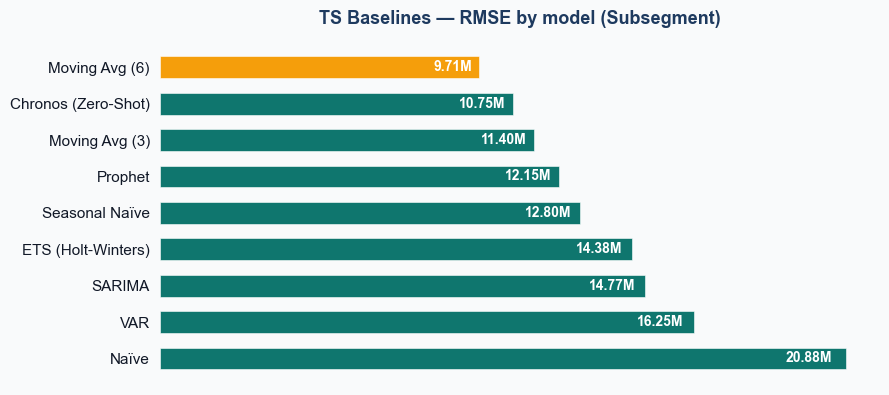

In [5]:
simple_bar(df_baselines, "RMSE", "TS Baselines — RMSE by model (Subsegment)", "#0F766E")


---
## 4. ML — Recursive Forecasting
### Notebook 6a) — Supervised ML with Recursive Engine, all hierarchy levels

ML models trained on 100 engineered features. The recursive engine predicts t+1,
recomputes lag features from that prediction, then predicts t+2, and so on.

**Key findings:**
- At **subsegment level**, Random Forest and LightGBM are the strongest — tree ensembles handle the heterogeneous series better than gradient boosting variants.
- Linear models (Ridge, Lasso, ElasticNet) **collapsed** at subsegment level (wMAPE > 5000%) — they require per-series normalisation to be viable at this granularity.
- At **segment and BU level**, linear models recover and XGBoost performs best.


In [6]:
for level in ["Subsegment", "Segment", "BU"]:
    df_lv = df_recursive[df_recursive["Level"] == level].copy()
    df_lv = df_lv.drop(columns=["Level"], errors="ignore")
    print(f"\n{'─'*60}\nLevel: {level}\n{'─'*60}")
    display(style_table(df_lv))



────────────────────────────────────────────────────────────
Level: Subsegment
────────────────────────────────────────────────────────────


,Model,RMSE,MAE,wMAPE,R2,Note
★,Random Forest,"12,920,387","7,235,794",19.80%,0.9625,—
,LightGBM,"13,847,374","8,934,442",24.50%,0.9569,—
,XGBoost,"25,332,555","22,247,216",60.90%,0.8559,—
,Gradient Boosting,"25,402,657","21,278,919",58.30%,0.8551,—
,Ridge,"1,977,049,782","1,952,121,726",5346.10%,—,Collapsed (wMAPE > 5000%)
,Lasso,"1,977,065,405","1,952,136,597",5346.10%,—,Collapsed
,ElasticNet,"1,977,146,095","1,952,191,943",5346.30%,—,Collapsed



────────────────────────────────────────────────────────────
Level: Segment
────────────────────────────────────────────────────────────


,Model,RMSE,MAE,wMAPE,R2,Note
,XGBoost,"36,513,280","20,652,000",8.20%,0.9879,—
,Gradient Boosting,"44,076,845","23,389,626",9.20%,0.9824,—
,Lasso,"44,473,927","25,213,573",10.00%,0.9821,—
,LightGBM,"48,201,518","22,096,562",8.70%,0.9790,—
,Ridge,"50,910,221","28,969,801",11.40%,0.9765,—
,ElasticNet,"56,008,064","29,060,447",11.50%,0.9716,—
,Random Forest,"65,257,949","29,486,363",11.60%,0.9614,—



────────────────────────────────────────────────────────────
Level: BU
────────────────────────────────────────────────────────────


,Model,RMSE,MAE,wMAPE,R2,Note
,Lasso,"87,582,302",—,—,0.7971,—
,LightGBM,"91,523,048",—,—,0.9208,—
,XGBoost,"97,587,643",—,—,0.9959,—
,Ridge,"98,203,316",—,—,0.7564,—
,Gradient Boosting,"101,541,346",—,—,0.9063,—
,Random Forest,"160,438,391",—,—,0.6050,—
,ElasticNet,"164,552,616",—,—,0.4715,—


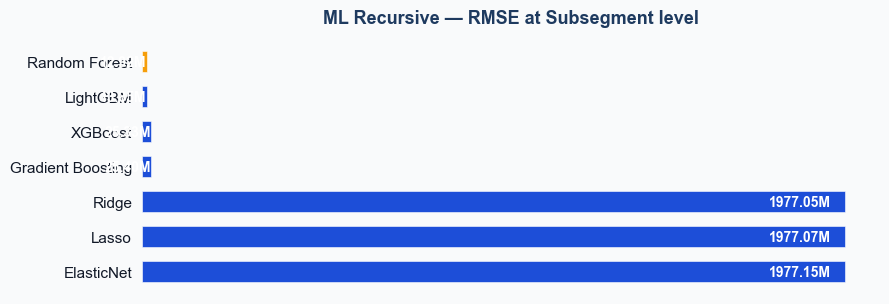

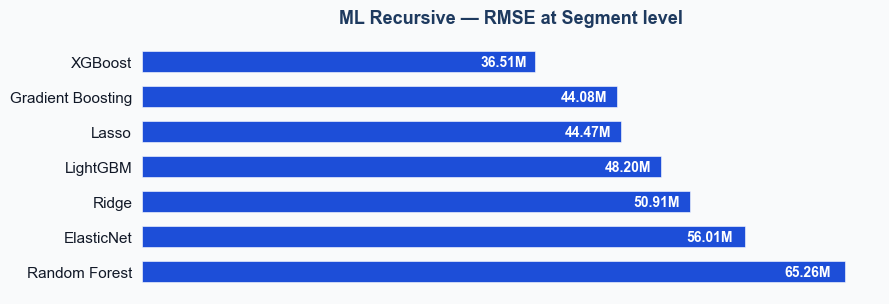

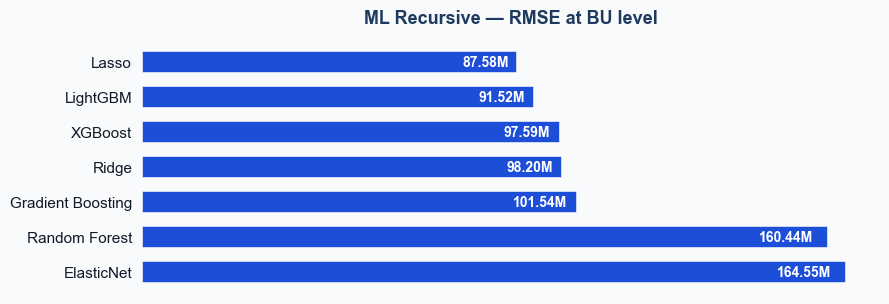

In [7]:
for level in ["Subsegment", "Segment", "BU"]:
    df_lv = df_recursive[(df_recursive["Level"]==level) & df_recursive["RMSE"].notna()].copy()
    simple_bar(df_lv, "RMSE",
               f"ML Recursive — RMSE at {level} level", "#1D4ED8")


---
## 5. ML — Direct Multi-Step Forecasting
### Notebook 6b) — One Model per Horizon h ∈ {1…6}

A separate model is trained for each forecasting horizon h. The target column y(t+h)
is constructed explicitly — no leakage by construction, no accumulated prediction error.

**Key findings:**
- At **subsegment level**, CatBoost achieves the best result (RMSE 10.27M) — a 20% improvement over the best recursive ML model.
- The direct approach consistently outperforms recursive at the subsegment granularity.
- At **BU level**, Random Forest leads (RMSE 120.5M, wMAPE 8.5%).


In [8]:
for level in ["Subsegment", "Segment", "BU"]:
    df_lv = df_direct[df_direct["Level"] == level].copy()
    df_lv = df_lv.drop(columns=["Level"], errors="ignore")
    print(f"\n{'─'*60}\nLevel: {level}\n{'─'*60}")
    display(style_table(df_lv))



────────────────────────────────────────────────────────────
Level: Subsegment
────────────────────────────────────────────────────────────


,Model,RMSE,MAE,wMAPE,R2
★,CatBoost,"10,270,056","5,446,644",14.08%,0.9773
,XGBoost,"11,327,380","5,175,391",13.38%,0.9724
,XGBoost (Optuna),"10,739,067",—,12.68%,0.9752
,Ridge (Linear),"11,395,822","6,944,689",17.95%,0.9721
,LightGBM,"12,101,632","5,254,137",13.58%,0.9685
,Random Forest,"13,625,487","5,983,083",15.47%,0.9601



────────────────────────────────────────────────────────────
Level: Segment
────────────────────────────────────────────────────────────


,Model,RMSE,MAE,wMAPE,R2
,XGBoost,"49,490,236","24,165,045",9.54%,0.9778
,LightGBM,"49,838,032","24,154,514",9.54%,0.9775
,Random Forest,"55,322,294","27,585,774",10.89%,0.9723
,CatBoost,"56,108,305","32,878,876",12.98%,0.9715
,Ridge (Linear),"51,675,486","34,826,621",13.75%,0.9758



────────────────────────────────────────────────────────────
Level: BU
────────────────────────────────────────────────────────────


,Model,RMSE,MAE,wMAPE,R2
,Random Forest,"120,543,173","85,704,644",8.46%,0.9526
,Ridge (Linear),"129,282,233","98,402,795",9.71%,0.9455
,XGBoost,"155,083,340","122,453,530",12.09%,0.9215
,LightGBM,"155,727,667","124,084,803",12.25%,0.9209
,CatBoost,"159,241,386","134,501,480",13.28%,0.9172


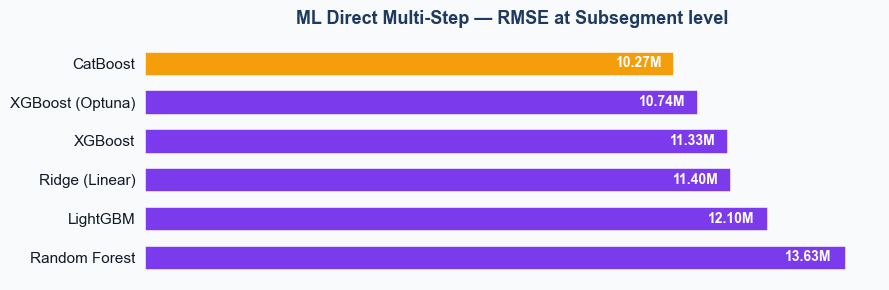

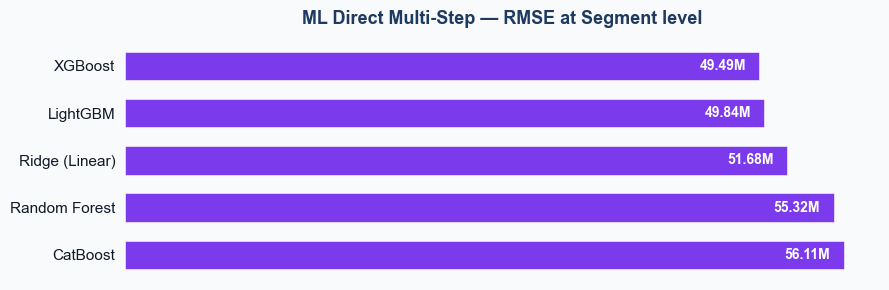

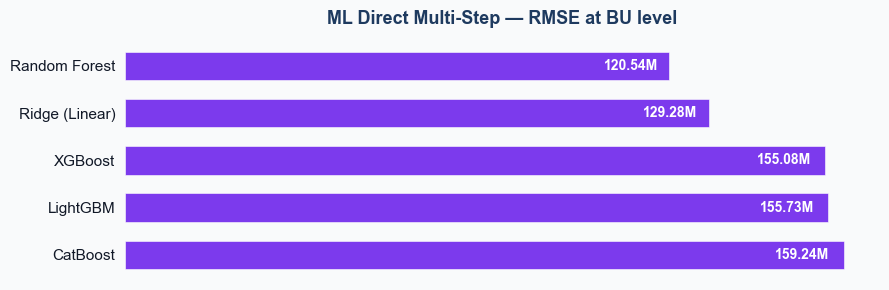

In [9]:
for level in ["Subsegment", "Segment", "BU"]:
    df_lv = df_direct[df_direct["Level"]==level].copy()
    simple_bar(df_lv, "RMSE",
               f"ML Direct Multi-Step — RMSE at {level} level", "#7C3AED")


---
## 6. Foundation Models (Zero-Shot)
### Notebook 6c) — Pre-trained Time Series Foundation Models

Models pre-trained on large corpora of time series data, applied zero-shot without fine-tuning.
They receive only the raw historical Revenue series as input.

**Key finding:** FlowState-r1.1 achieves the **best overall result across all approaches** —
RMSE 7.70M and wMAPE 9.3%, outperforming the Moving Average baseline by **21% on RMSE**.
This is a remarkable result given zero knowledge of our specific data distribution.

> Note: MAE was not recorded for these models.


In [10]:
style_table(df_pretrained)

,Model,RMSE,MAE,wMAPE,R2
★,FlowState-r1.1,"7,703,018",—,9.30%,0.9873
,Chronos-2,"8,349,693",—,9.90%,0.9850
,TimesFM-2.5,"9,182,434",—,11.40%,0.9819


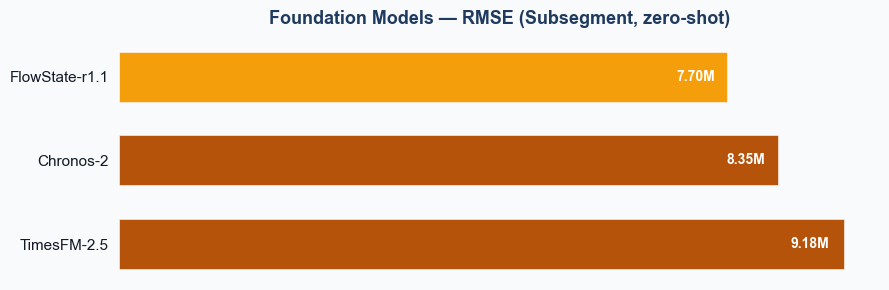

In [11]:
simple_bar(df_pretrained, "RMSE",
           "Foundation Models — RMSE (Subsegment, zero-shot)", "#B45309")


---
## 7. Walk-Forward Validation
### Notebook 6d) — Expanding Window Cross-Validation (6 Folds)

Walk-forward CV trains on all data up to period t, predicts t+1 through t+6,
advances t, and repeats. Results are **averaged across 6 folds**.

This produces more robust and conservative performance estimates than a single split,
as each model is evaluated across multiple temporal windows.

**Key findings:**
- XGBoost achieves the best subsegment RMSE (7.41M), closely followed by LightGBM.
- At segment level XGBoost also leads (RMSE 12.2M, wMAPE 7%).
- At BU level LightGBM edges XGBoost (79.6M vs 79.8M).
- R²≈1.0 for all models is an artefact of the R² calculation within folds — **RMSE and wMAPE are the meaningful metrics here.**


In [12]:
for level in ["Subsegment", "Segment", "BU"]:
    df_lv = df_wf[df_wf["Level"] == level].copy()
    df_lv = df_lv.drop(columns=["Level","R2"], errors="ignore")
    print(f"\n{'─'*60}\nLevel: {level}  (avg across 6 folds)\n{'─'*60}")
    display(style_table(df_lv))



────────────────────────────────────────────────────────────
Level: Subsegment  (avg across 6 folds)
────────────────────────────────────────────────────────────


,Model,RMSE,MAE,wMAPE
★,XGBoost,"7,405,830","3,634,914",11.00%
,LightGBM,"7,650,552","3,479,706",10.00%
,Gradient Boosting,"9,119,385","4,665,043",14.00%
,Random Forest,"9,555,545","4,518,534",13.00%
,Ridge,"10,149,099","6,204,958",18.00%
,Lasso,"10,172,420","6,398,722",19.00%
,ElasticNet,"25,845,811","15,578,352",46.00%



────────────────────────────────────────────────────────────
Level: Segment  (avg across 6 folds)
────────────────────────────────────────────────────────────


,Model,RMSE,MAE,wMAPE
,XGBoost,"12,204,052","2,767,648",7.00%
,LightGBM,"13,458,034","3,246,081",8.00%
,Random Forest,"14,800,221","3,663,795",9.00%
,Gradient Boosting,"15,374,901","3,664,800",9.00%
,Lasso,"18,307,816","5,527,285",13.00%
,ElasticNet,"18,333,307","5,118,948",12.00%
,Ridge,"18,489,987","5,487,408",13.00%



────────────────────────────────────────────────────────────
Level: BU  (avg across 6 folds)
────────────────────────────────────────────────────────────


,Model,RMSE,MAE,wMAPE
,LightGBM,"79,567,159","64,760,391",6.00%
,XGBoost,"79,799,423","60,455,591",6.00%
,Ridge,"88,226,217","72,580,115",7.00%
,Lasso,"89,396,968","72,306,495",7.00%
,Gradient Boosting,"92,174,763","66,486,224",7.00%
,Random Forest,"108,094,495","82,780,969",8.00%
,ElasticNet,"206,984,115","186,006,714",18.00%


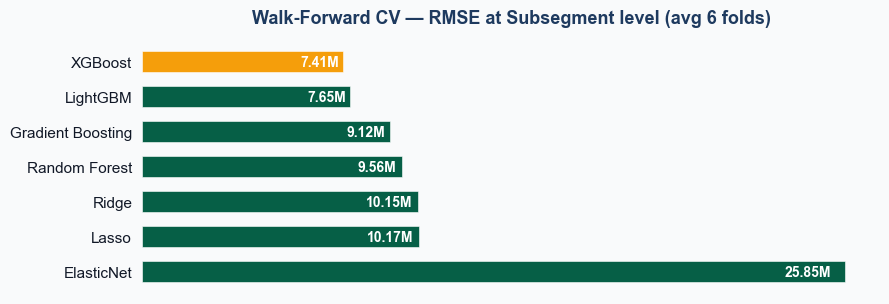

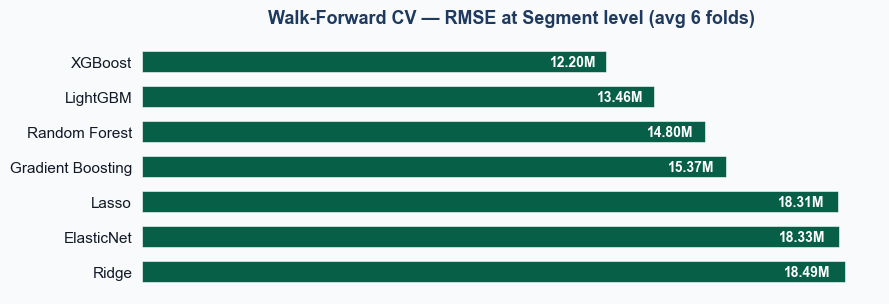

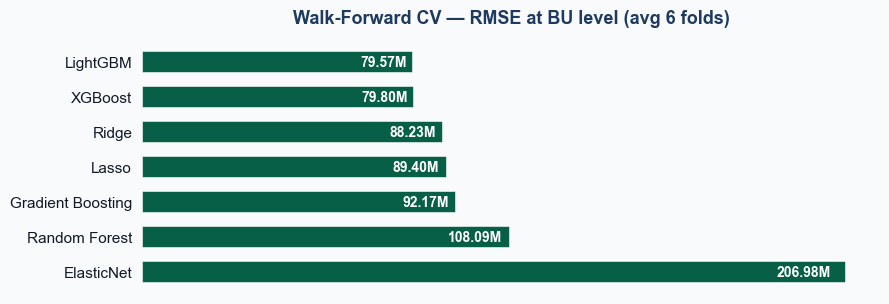

In [13]:
for level in ["Subsegment", "Segment", "BU"]:
    df_lv = df_wf[df_wf["Level"]==level].copy()
    simple_bar(df_lv, "RMSE",
               f"Walk-Forward CV — RMSE at {level} level (avg 6 folds)", "#065F46")


---
## 8. Overall Comparison — Best Model per Approach

Consolidating the winner of each approach at **subsegment level** (primary evaluation level).

> Walk-Forward R² reported as 1.0 is a known artefact — interpret RMSE and wMAPE only for that row. The 1.0 value its because its rounded


In [14]:
df_summary = pd.DataFrame([
    {"Approach": "TS Baselines",         "Best Model": "Moving Avg (6)",  "Notebook": "6a",
     "RMSE": 9_709_532,  "MAE": 4_588_482, "wMAPE": 12.0,  "R2": 0.9796},
    {"Approach": "ML Recursive",         "Best Model": "Random Forest",   "Notebook": "6a",
     "RMSE": 12_920_387, "MAE": 7_235_794, "wMAPE": 19.8,  "R2": 0.9625},
    {"Approach": "ML Direct Multi-Step", "Best Model": "XGBoost (Optuna)",  "Notebook": "6b",
     "RMSE": 10_739_067, "MAE": None,     "wMAPE": 12.68, "R2": 0.9752},
    {"Approach": "Foundation Models",    "Best Model": "FlowState-r1.1",  "Notebook": "6c",
     "RMSE": 7_703_018,  "MAE": None,      "wMAPE":  9.3,  "R2": 0.9873},
    {"Approach": "Walk-Forward CV",      "Best Model": "XGBoost",         "Notebook": "6d",
     "RMSE": 7_405_830,  "MAE": 3_634_914, "wMAPE": 11.0,  "R2": 1.0},
])

def highlight_summary(df):
    styled = df.style.format({
        "RMSE":  "{:,.0f}",
        "MAE":   "{:,.0f}",
        "wMAPE": "{:.2f}%",
        "R2":    "{:.4f}",
    }, na_rep="—")

    for col, best_fn in [("RMSE", min), ("MAE", min), ("wMAPE", min), ("R2", max)]:
        vals = df[col].dropna()
        if vals.empty:
            continue
        best_val = best_fn(vals)
        # use .map() — compatible with all pandas versions
        styled = styled.map(
            lambda v, bv=best_val: (
                "background-color:#d1fae5; font-weight:bold; color:#065f46"
                if v == bv else ""
            ),
            subset=[col]
        )

    styled = styled.set_table_styles([
        {"selector": "th", "props": [
            ("background-color","#1e3a5f"), ("color","white"),
            ("font-size","12px"), ("text-align","center"), ("padding","8px 14px")]},
        {"selector": "td", "props": [
            ("font-size","13px"), ("padding","7px 14px"),
            ("border-bottom","1px solid #e5e7eb")]},
    ]).hide(axis="index")
    return styled

highlight_summary(df_summary)


Approach,Best Model,Notebook,RMSE,MAE,wMAPE,R2
TS Baselines,Moving Avg (6),6a,"9,709,532","4,588,482",12.00%,0.9796
ML Recursive,Random Forest,6a,"12,920,387","7,235,794",19.80%,0.9625
ML Direct Multi-Step,XGBoost (Optuna),6b,"10,739,067",—,12.68%,0.9752
Foundation Models,FlowState-r1.1,6c,"7,703,018",—,9.30%,0.9873
Walk-Forward CV,XGBoost,6d,"7,405,830","3,634,914",11.00%,1.0000


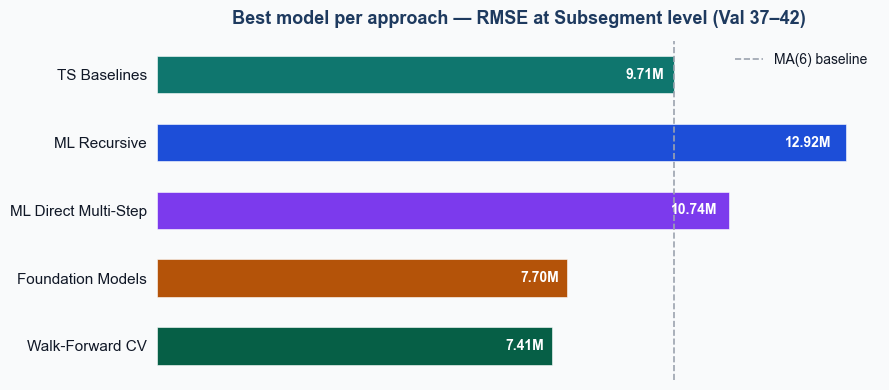

In [15]:
# Summary RMSE bar — one bar per approach, coloured by approach
fig, ax = plt.subplots(figsize=(9, 4))

colors = [APPROACH_COLORS.get(a, "#64748B") for a in df_summary["Approach"]]
bars = ax.barh(df_summary["Approach"], df_summary["RMSE"],
               color=colors, edgecolor="white", linewidth=0.4, height=0.55)

# baseline reference line
baseline = df_summary.loc[df_summary["Approach"]=="TS Baselines", "RMSE"].values[0]
ax.axvline(baseline, color="#9CA3AF", linestyle="--", linewidth=1.2, label="MA(6) baseline")

for bar, val in zip(bars, df_summary["RMSE"]):
    ax.text(bar.get_width() - bar.get_width()*0.02, bar.get_y()+bar.get_height()/2,
            f"{val/1e6:.2f}M", va="center", ha="right", fontsize=10,
            color="white", fontweight="bold")

ax.set_title("Best model per approach — RMSE at Subsegment level (Val 37–42)",
             fontsize=13, fontweight="bold", color="#1e3a5f", pad=12)
ax.invert_yaxis()
ax.set_xlim(right=df_summary["RMSE"].max()*1.05)
ax.spines[["top","right","left","bottom"]].set_visible(False)
ax.tick_params(left=False, bottom=False, labelsize=11, colors="#111827")
ax.set_yticklabels(df_summary["Approach"], fontsize=11, color="#111827")
ax.xaxis.set_visible(False)
ax.grid(False)
ax.legend(fontsize=10, labelcolor="#111827", framealpha=0)
ax.set_facecolor("#F9FAFB")
fig.patch.set_facecolor("#F9FAFB")
plt.tight_layout()
plt.show()

---
## 9. Conclusions & Recommendations

### Summary of findings

| Finding | Detail |
|---|---|
| **Best overall model** | FlowState-r1.1 (zero-shot) — RMSE 7.70M, wMAPE 9.3%, R² 0.9873 |
| **Best supervised ML** | CatBoost Direct Multi-Step — RMSE 10.27M, wMAPE 14.1% |
| **Strongest baseline** | Moving Average (window=6) — RMSE 9.71M, sets a hard-to-beat reference |
| **Recursive ML** | Underperforms direct approach — error accumulation penalises long horizons |
| **Linear models** | Collapsed at subsegment granularity; viable only at segment/BU with regularisation |
| **Walk-Forward CV** | XGBoost RMSE 7.41M — most honest estimate (averaged across 6 folds) |

### Recommended strategy (middle-out hybrid)

Given the results, a **middle-out hybrid** approach is recommended for the final submission:

1. **FlowState-r1.1** for series with sufficient historical signal — best raw accuracy, no training required.
2. **CatBoost Direct Multi-Step** as the primary supervised ML fallback.
3. **Moving Average (window=6)** for erratic / low-volume subsegments where ML overfits.
4. **Zero** for dead series (revenue = 0 for consecutive periods with no orders).

### Open items

- [ ] MinT hierarchical reconciliation (6a, 6b) — coherent forecasts across levels
- [ ] Fine-tuning foundation models on domain data — potential further gains


---
## 10. Export Results

Export all tables to Excel and CSV.

In [16]:
import os

output_dir = "../data/results"
os.makedirs(output_dir, exist_ok=True)

with pd.ExcelWriter(f"{output_dir}/benchmarking_results.xlsx", engine="openpyxl") as writer:
    df_summary.to_excel(writer,    sheet_name="Summary",         index=False)
    df_baselines.to_excel(writer,  sheet_name="6a_Baselines",    index=False)
    df_recursive.to_excel(writer,  sheet_name="6a_ML_Recursive", index=False)
    df_direct.to_excel(writer,     sheet_name="6b_ML_Direct",    index=False)
    df_pretrained.to_excel(writer, sheet_name="6c_Foundation",   index=False)
    df_wf.to_excel(writer,         sheet_name="6d_WalkForward",  index=False)

df_summary.to_csv(f"{output_dir}/benchmarking_summary.csv", index=False)

print(f"✓ Exported to {output_dir}/")
print("  benchmarking_results.xlsx  (6 sheets)")
print("  benchmarking_summary.csv")


✓ Exported to ../data/results/
  benchmarking_results.xlsx  (6 sheets)
  benchmarking_summary.csv
